<a href="https://colab.research.google.com/github/SaanviAtluri/SaanviAtluri/blob/main/copy_MNIST_Code_Review_w_Validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MNIST Code

<hgroup>
<h4><i>CS106EA Exploring Artificial Intelligence</i></h4>
<h4><i>Patrick Young, Stanford University</i></h4>
</hgroup>

Our objective in this Notebook is to give you a chance to actually look at the Python code associated with one of our Colab Notebooks.  There are two versions of this file.  **This is the complex version**, it includes Validation in addition to Training and Testing Datasets.  The training loop includes additional complications to support Early Stopping.  If you actually run the code (which is not required with this particular Notebook for this assignment) you'll need to run it considerably longer if you want to see Early Stopping in action.  The Validation Data continues to improve (indicating no Overfitting is occuring until somewhere between 50 and 60 Epochs).

You are welcome to use either version of the Notebook for the homework.

## Basic Setup

### Imports

We'll start with importing libraries we need.

The bulk of our libraries are part of PyTorch.  We'll load both the standard PyTorch libraries and the more specialized TorchVision which is designed for processing images (our MNIST data are 28*28 pixel greyscale images).

In addition we'll use MatPlotLib for plotting.

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split

import torchvision

from torchvision import datasets, transforms

import matplotlib.pyplot as plt

import random
import time
import copy

### Check Environment

Typically we'll determine what sort of environment we're working with.  In many of these Notebooks we'll determine if we're working with Colab and will open a connection to Google Drive.  We won't actually use Google Drive in this Notebook, but I've left the code to check if we're on Colab in so you you can take a look at it.

We'll also check to see if we're using an NVIDIA GPU.  If we are, we can move our Tensors to the GPU to speed our processing.  If we aren't we'll do our processing on the CPU, which is less efficient.  Typically since the system will have less GPU memory than regular main memory, we'll move things to the GPU at the last minute, so you won't see any further reference to the Device we're working with until the actual training loop.

In [ ]:
try:
    import google.colab
    running_on_colab = True
except ImportError:
    running_on_colab = False

if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

## Load Dataset

MNIST is "available" as part of PyTorch, but in fact what this really means is that PyTorch knows where to download the MNIST data from.  It is possible to store this data between uses of this Colab notebook rather then reloading everytime you reopen the notebook, but this will require access to your Google Drive, which we are not doing for this example.

You can watch PyTorch's TorchVision try to download MNIST the MNIST data as you execute this next Python cell.

In [ ]:
# mean and std_dev are standard known weights for MNIST
mean = 0.1307
std_dev = 0.3081

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std_dev)
])

training_images = datasets.MNIST("MNIST_data", transform=transform,
                                         download=True,train=True)
testing_images = datasets.MNIST("MNIST_data", transform=transform,
                                         download=True,train=False)

# MNIST originally only had Training and Validation Datasets
# We'll explicitliy pull 10,000 samples out of Training for Validation

# Specify the sizes for training and validation datasets
validation_size = 10_000  # Exactly 10,000 items for validation
training_size = len(training_images) - validation_size  # Remaining for training

# Split the training dataset
training_images, validation_images = random_split(training_images, [training_size, validation_size])


## Define Neural Network

Here we define a relatively simple network.  We start by flattening our 2D 28x28 pixel input into a single dimensional tensor input to the rest of the network.  This is followed by two hidden layers, each with 512 nodes and using the ReLU (Rectified Linear Unit) activation function.  The final layer is our output layer which reduces the 512 values passed to it down to just 10 (corresponding to the 10 possible digits).  

Our network normally just outputs logits, which are not limited to values summing to 100%.  I've added an additional method which converts to these logits to numbers which will sum to 100% and can thus be interpreted as percentages.  This uses Softmax which is one of our specialized Activation Functions sometimes used on outputs to make the interpretable.

In [ ]:
class MNISTBasicNetwork(nn.Module):

    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512,512),
            nn.ReLU(),
            nn.Linear(512,10)
        )

    def forward(self, network_input):
        return self.layers(network_input)  # Return raw logits

    def predict_with_softmax(self, inputs):
        """
        Perform a forward pass and apply softmax to get probabilities.
        """
        self.eval()  # Ensure the model is in evaluation mode
        with torch.no_grad():  # Disable gradient calculations
            logits = self.forward(inputs)  # Get raw logits
            probabilities = nn.functional.softmax(logits, dim=1)  # Convert to probabilities
        return probabilities

## Training

This training loop includes a check to see if Validation Loss continues to drop.  Each time it drops, we create a checkpoint of our current parameters as they represent the best parameter settings we've seen so far.  If Validation rises, we don't update our checkpoint, we also check to see how long Validation Loss has been rising.  When the total number of consecutive rises exceeds the Hyperparameter PATIENCE, we drop out of our training loop.  Otherwise we train until we reach a preset number of Epochs.

Once we terminate our training, we load the best parameter settings for the model, potentially replacing the last set of parameters.  For example, if our Validation Loss continued to rise and we ended up terminating, we don't want the ending set of parameters, we want the best set of parameters.

The number of epochs is set to 80, which should be long enough to reliably trigger Early Stopping. In most cases, this occurs between epochs 50 and 65, but this can vary due to the non-deterministic nature of training.  This will take quite a long time running on Colab. You don't actually need to run this Code Cell for this part of this week's homework assignment.  The main point for this Notebook is just to have you look over the code.  However, you can certainly run it in the background while you're doing something else if you want to see how the Early Stopping works.

If you hit the run icon for the Code Cell below and then scroll to the output at the bottom of the cell you can see the actual training occur as loss numbers will be printed as each epoch completes.

In [ ]:
# These are all examples of hyperparameters
# changing hyperparameters may have a big impact on the speed of learning
# and in some cases the actual results as certain hyperparameter settings
# will reduce the risk of getting stuck in a local minima or maxima instead
# of reaching the actual global minimum or maximum
NUMBER_OF_EPOCHS = 80
LEARNING_RATE = 0.02
BATCH_SIZE = 128
PATIENCE = 4
   # PATIENCE determines how many Epochs to continue training after Validation Loss
   # firsts starts rising.  Loss can be noisy, so one or two Epochs of Loss rising
   # doesn't necessarily indicate no future improvements are possible

PRINT_RATE = 1  # how often we should print results

network = MNISTBasicNetwork().to(device)

training_loader = DataLoader(training_images, batch_size=BATCH_SIZE, shuffle=True)
validation_loader = DataLoader(validation_images, batch_size=BATCH_SIZE, shuffle=False)
testing_loader = DataLoader(testing_images, batch_size=BATCH_SIZE, shuffle=False)

loss_func = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(network.parameters(),lr = LEARNING_RATE)
network.train()

start_time = time.time()

best_loss = float('inf')  # set initial best loss to infinity, so first real value is lower
best_state = None # use to store best parameter values
validation_loss_increasing_epochs = 0  # number of epochs validation loss has risen instead of fallen

for epoch in range(1,NUMBER_OF_EPOCHS+1):
    total_instances = 0
    total_loss = 0
    total_validation_instances = 0
    total_validation_loss = 0

    network.train()  # for training switch model to training mode
    for img_batch, label_batch in training_loader:
        img_batch, label_batch = img_batch.to(device), label_batch.to(device)
        result_batch = network(img_batch)
        loss = loss_func(result_batch, label_batch)

        mini_batch_size = len(img_batch)  # batch size may be different for last batch
        total_instances += mini_batch_size
        total_loss += mini_batch_size * loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    network.eval()  # for validation, switch model to inference mode
    with torch.no_grad():
        for img_batch, label_batch in validation_loader:
            img_batch, label_batch = img_batch.to(device), label_batch.to(device)
            result_batch = network(img_batch)
            loss = loss_func(result_batch, label_batch)

            mini_batch_size = len(img_batch)
            total_validation_instances += mini_batch_size
            total_validation_loss += mini_batch_size * loss.item()

    # if the results are the best we've seen so far, save them if they aren't, see if we should terminate
    if total_validation_loss < best_loss:  # this is actually sum of loss, but that shouldn't matter
        best_loss = total_validation_loss
        best_state = copy.deepcopy(network)
        validation_loss_increasing_epochs = 0
    else:
        validation_loss_increasing_epochs += 1
        if validation_loss_increasing_epochs > PATIENCE:
            early_termination = True
            break

    if epoch % PRINT_RATE == 0:
        print(f"epoch: {epoch}, loss: {(total_loss/total_instances):.4f}, "
                f"validation loss: {(total_validation_loss/total_validation_instances):.4f}")

if early_termination:
    print(f"epoch: {epoch}, loss: {(total_loss/total_instances):.4f}, "
                f"validation loss: {(total_validation_loss/total_validation_instances):.4f}")
    print(f"Terminated Early after {epoch} Epochs")

network = best_state

end_time = time.time()
print(f"Training time: {(end_time - start_time):.2f} seconds")

epoch: 1, loss: 0.8134, validation loss: 0.3546
epoch: 2, loss: 0.3172, validation loss: 0.2765
epoch: 3, loss: 0.2586, validation loss: 0.2393
epoch: 4, loss: 0.2210, validation loss: 0.2077
epoch: 5, loss: 0.1923, validation loss: 0.1877
epoch: 6, loss: 0.1692, validation loss: 0.1707
epoch: 7, loss: 0.1506, validation loss: 0.1536
epoch: 8, loss: 0.1354, validation loss: 0.1409
epoch: 9, loss: 0.1218, validation loss: 0.1339
epoch: 10, loss: 0.1109, validation loss: 0.1259
epoch: 11, loss: 0.1010, validation loss: 0.1197
epoch: 12, loss: 0.0927, validation loss: 0.1129
epoch: 13, loss: 0.0848, validation loss: 0.1063
epoch: 14, loss: 0.0784, validation loss: 0.1032
epoch: 15, loss: 0.0720, validation loss: 0.0998
epoch: 16, loss: 0.0671, validation loss: 0.0952
epoch: 17, loss: 0.0620, validation loss: 0.0953
epoch: 18, loss: 0.0578, validation loss: 0.0920
epoch: 19, loss: 0.0538, validation loss: 0.0879
epoch: 20, loss: 0.0499, validation loss: 0.0854
epoch: 21, loss: 0.0466, vali

## Testing

In this next code cell we use our testing data to determine how well our training worked.  Remember we have a clear separation between data used for training the network and a second set of data that the network has not yet seen.  Our assumption is that the network will have learned the patterns found in the training data, so it should give good results when tested on the training data, but those good results might be limited only to the specific samples our network trained on.  In fact our network may start focusing too much on the specific training samples themselves losing focus on the more generalized phenomena we are trying to model (this is called "overfitting" and we'll explore it in another problem in this HW assignmment).  The test set will resemble actual live "production" data that the model has not been trained on.  Thus the accuracy statistics on the testing data should match that of the network during actual use with new data, whereas the network's accuracy on the training data will likely be higher than that on unseen data.

The accuracy here should actually be better than in HW1 example which was trained on 20 Epochs.  But you'll see it's not that much better (and may not justify the additional training time and expense).

In [ ]:
test_loader = DataLoader(testing_images, batch_size=BATCH_SIZE, shuffle=False)

total_correct = 0

network.eval()
with torch.no_grad():
    for img_batch, label_batch in test_loader:
        img_batch, label_batch = img_batch.to(device), label_batch.to(device)

        result_batch = network(img_batch)
        _, predicted_batch = torch.max(result_batch, 1)

        total_correct += (predicted_batch == label_batch).sum().item()

print(f"Accuracy: {(100 * total_correct / len(test_loader.dataset)):.3f}")

Accuracy: 97.810


# Production Use

We'll simulate production use of our network by randomly loading an element from our testing set and seeing how it performs.

What you'll see output here is what percentage chance the neural network thinks the input image represents the digits 0 to 9 along with the actual image input.

Re-run the code cell if you want to see how the network classifies different images.

0: 0.0001
1: 0.0000
2: 0.0000
3: 0.0004
4: 0.0000
5: 0.0002
6: 0.0000
7: 0.0000
8: 99.9986
9: 0.0006
Actual Label: 8


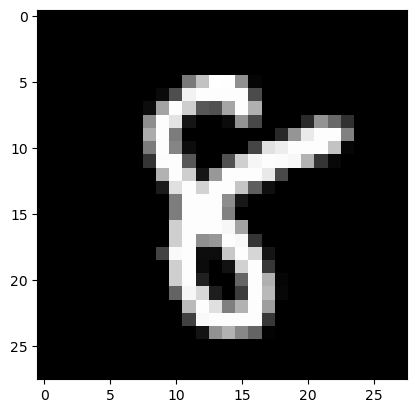

In [ ]:
rand_index = random.randint(0,len(testing_images) - 1)
img, label = testing_images[rand_index]
img = img.to(device)  # move to GPU if present

result = network.predict_with_softmax(img.unsqueeze(0))
        # the unsqueeze adds an extra dimension as the network itself is setup to handle
        # mini-batches not individual instances
        # we're essentially creating a mini-batch of size 1

result_list = result.cpu().tolist()

for i, result in enumerate(result_list[0]):
    print(f"{i}: {result*100:.4f}")

print(f"Actual Label: {label}")
actual_image = img * std_dev + mean  # return image to pre-normalized state for output
plt.imshow(actual_image.squeeze(0).cpu(), cmap="gray")
